# **2º Taller de laboratorio del curso "Identificación de locutores"**
Revisión 24 de Marzo de 2026

**Trabajo de laboratorio No.2. Entrenamiento de un detector de actividad vocal**

**Objetivo del trabajo:** estudiar el procedimiento de construcción de un detector de actividad vocal basado en un modelo de mezcla de gaussianas (GMM).

**Breve descripción:** en el presente trabajo de laboratorio se propone estudiar e implementar un detector de actividad vocal, usando la energía de la señal de habla, basado en un modelo de mezcla de gaussianas (Gaussian Mixture Model, GMM). La implementación de cualquier detector debe ir acompañada de una evaluación subjetiva y objetiva de su calidad. Con ese propósito, y conforme a unas métricas objetivo, evaluaremos nuestro detector tanto en condiciones ideales como en presencia de ruido y reverberación.

**Datos:** Se propone utilizar la parte de test de la base de datos [VoxCeleb1] (http://www.robots.ox.ac.uk/~vgg/data/voxceleb/vox1.html).

**Contenido del laboratorio**

1. Preparación de los datos para entrenar y evaluar el detector de actividad vocal.

2. Aprender el formato de archivo RTTM.

3. Implementación de un detector de actividad vocal basado en un modelo de mezcla de Gaussianas (GMM).

4. Corrección de la segmentación o marcado realizado por el detector utilizando métodos de procesamiento morfológico.

5. Evaluación del detector de actividad vocal implementado en condiciones ideales (con datos "limpios").

6. Evaluación del detector de actividad vocal implementado en condiciones ruidosas.

## **Paso 1) Preparación de los datos.**

In [1]:
!pip install PyDrive
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 17.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for PyDrive: filename=PyDrive-1.3.1-py3-none-any.whl size=27433 sha256=8084b3d5c7db817d565b15359eab710d00fbff8bf1f1d54e557fcbf7d5adf011
  Stored in directory: /root/.cache/pip/wheels/6c/10/da/a5b513f5b3916fc391c20ee7b4633e5cf3396d570cdd74970f
Successfully built PyDrive


### Conexión con Google Drive para recuperar los ficheros con los datos
Autorice el acceso con su ID de Google, pegue el enlace que aparece y presione "Enter"

In [46]:
from google.colab import drive
drive.mount('/gdrive')
# Clonar el repositorio sin descargar todo el contenido
!git clone --filter=blob:none --no-checkout https://github.com/efhes/IDLO.git

%cd IDLO

# Activar sparse checkout
!git sparse-checkout init --cone

# Seleccionar las carpetas necesarias
!git sparse-checkout set common data lab2

# Descargar solo esas carpetas
!git checkout

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
Cloning into 'IDLO'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 18 (delta 5), reused 18 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), done.
Resolving deltas: 100% (5/5), done.
/content/IDLO/IDLO
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 60 (delta 14), reused 59 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 1.04 MiB | 3.78 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Your branch is up to date with 'origin/main'.


In [3]:
!pip install tqdm requests
#!pip install --upgrade ipython

In [47]:
import importlib, sys
from types import ModuleType

# Create a dummy 'imp' module
imp = ModuleType('imp')
imp.reload = importlib.reload
sys.modules['imp'] = imp

# Now try loading the extension
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
# Import of modules
import os
import sys

sys.path.append(os.path.realpath('..'))

from math import sqrt, pi

import numpy as np
from matplotlib.pyplot import figure, plot, show, grid, title, xlabel, ylabel, legend, hist

from skimage.morphology import opening, closing
from torchaudio.transforms import Resample
import torchaudio

from common.dataprep import download_dataset, extract_dataset
from lab2.exercises_solutions import download_dataset_UPM
from lab2.exercises_solutions import load_vad_markup, framing, frame_energy, norm_energy, gmm_train, eval_frame_post_prob, energy_gmm_vad, reverb, awgn

**1. Preparación de datos para entrenar y evaluar el detector de actividad vocal**

Durante la práctica, necesitamos datos para poder completar el entrenamiento y la evaluación del detector de actividad vocal implementado. Usaremos como datos varias grabaciones sonoras de voces masculinas y femeninas guardadas en formato *wav*, seleccionadas del corpus [VoxCeleb1 test set] (https://thor.robots.ox.ac.uk/~vgg/data/voxceleb/vox1a/vox1_test_wav.zip). Este corpus contiene un total de 4874 grabaciones de audio (frecuencia de muestreo de 16 kHz) de 40 hablantes masculinos y femeninos hablando en inglés.

A continuación, descargaremos y descomprimiremos los archivos wav de audio de la partición de test del dataset VoxCeleb1.

Figura 1. "VoxCeleb. A large scale audio-visual dataset of human speech".
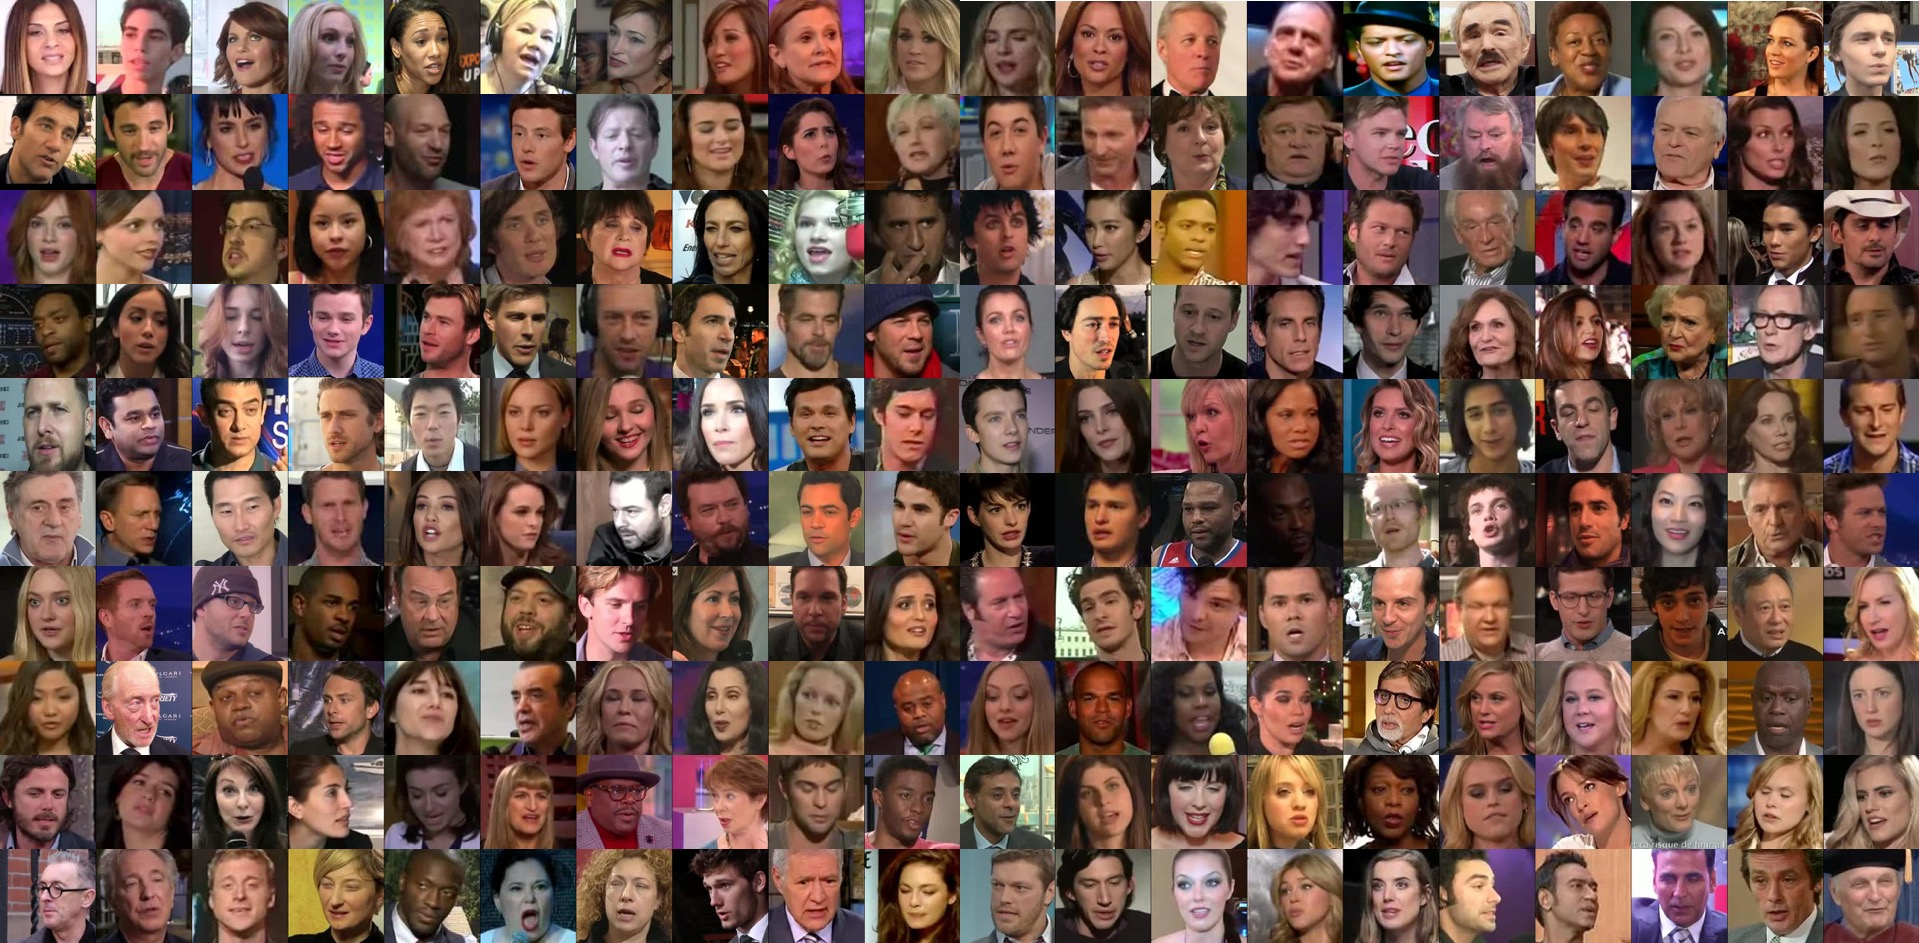


### Descarga de los datos

In [53]:
# Download VoxCeleb1 (test set)
#with open('./data/lists/datasets.txt', 'r') as f:
with open('./data/lists/dataset-test.txt', 'r') as f:
    lines = f.readlines()

download_dataset(lines, user='voxceleb1902', password='nx0bl2v2', save_path='./data')

vox1_test_wav.zip:   0%|          | 0.00/1.00G [00:00<?, ?iB/s]

Checksum successful vox1_test_wav.zip.


### Extracción de los datos

In [54]:
# Extract VoxCeleb1 test set
extract_dataset(save_path='./data/voxceleb1_test', fname='./data/vox1_test_wav.zip')

Extracting ./data/vox1_test_wav.zip:   0%|          | 0/5591 [00:00<?, ?it/s]

Extracting of ./data/vox1_test_wav.zip is successful.


Use la siguiente celda para descargar los datos si observa que la descarga mediante el método anterior no progresa o lo hace muy lentamente. Como alternativa adicional también puede probar a descargar el fichero .zip usando la URL especificada directamente desde cualquier navegador y posteriormente descomprimiendo y añadiendo su contenido al directorio **./data/voxceleb1_test/** dentro de la misma carpeta de su unidad de Google Drive en la que se encuentre copiado el presente notebook.

### Método alternativo para la consecución de los datos
**Ejecutar sólo en caso de que no haya funcionado el método anterior.**

In [ ]:
download_dataset_UPM('https://drive.upm.es/s/qq1prIg3OXqqZT1/download', save_path='./data')
extract_dataset(save_path='./data/voxceleb1_test', fname='./data/vox1_test_wav.zip')

##**Paso 2) Familiarizándonos con el formato de archivo RTTM**

Los *archivos de transcripción enriquecida con marcas temporales* (RTTM, Rich Transcription Time Marked) son archivos de texto en los que cada línea del fichero contiene un conjunto de metadatos o anotaciones individuales disponibles asociadas con la ocurrencia de un cierto evento de relevancia dentro de una grabación de audio. Dichos metadatos, separados por espacios, incluyen, además de un identificador del tipo de evento, las marcas temporales correspondientes al instante en que da comienzo el evento y su duración. En particular, cada línea del archivo rttm (ver documento en "./IDLO/lab2/docs/rt09_meeting_eval_plan_v2.pdf") corresponde a la anotación específica de un determinado evento o fragmento. Los tipos de anotaciones asociados con cada grabación varían en relación con el problema que se está resolviendo. Por ejemplo, cuando pretendemos emplear las anotaciones para resolver un problema de *diarización*, el marcado de cada archivo rttm debería contener una línea por cada una de las distintas intervenciones de cada locutor que participa en la grabación. El objeto de la anotación en dicho caso tendría por objetivo identificar los instantes temporales en los que comienzan y acaban las intervenciones de todos los locutores que participan de la grabación. En el caso de querer resolver el problema de construir un detector de actividad vocal, el marcado del archivo rttm contiene en cada línea metadatos asociados a los segmentos de voz presentes en la grabación de audio. En este caso no se pretende distinguir qué fragmentos corresponden a cada locutor sino simplemente cuáles corresponden a voz y cuales no.

Cada línea del archivo rttm contiene 10 campos. De los campos presentes en el archivo rttm, en esta práctica utilizaremos los siguientes:

- *campo 1*, tipo de evento a anotar (en nuestro caso denotado como SPEAKER, correspondiente a los tramos de voz de los diferentes hablantes),
- *campo 2*, nombre del archivo sin especificar ruta al mismo y extensión,
- *campo 3*, número del canal al que está asociado el segmento de voz, por ejemplo, "1" o "2",
- *campo 4*, instante de inicio del segmento de voz en segundos,
- *campo 5*, duración del segmento de voz en segundos,
- finalmente los *Campos* 6, 7, 8, 9 y 10 se considerarán indefinidos.

A continuación se muestra un posible ejemplo de una parte de un archivo RTTM para una determinada grabación.

SPEAKER 00006 1 3.186 1.733 \<NA\> \<NA\> \<NA\> \<NA\> \<NA\>  
SPEAKER 00006 1 5.253 1.043 \<NA\> \<NA\> \<NA\> \<NA\> \<NA\>  
SPEAKER 00006 1 6.376 2.007 \<NA\> \<NA\> \<NA\> \<NA\> \<NA\>  
SPEAKER 00006 1 8.796 0.676 \<NA\> \<NA\> \<NA\> \<NA\> \<NA\>  

El siguiente código propone analizar el contenido del directorio ./IDLO/lab2/ground_truth/rttm/, que contiene las anotaciones en formato RTTM de los segmentos con actividad vocal  identificados y marcados manualmente para algunas de las grabaciones del conjunto de test de la base de datos VoxCeleb1. Estas marcas de referencia serán utilizadas para evaluar la calidad de nuestro detector de actividad vocal. Tenga en cuenta que las marcas de referencia de las grabaciones de sonido para "habla" y "no habla" se obtuvieron utilizando la herramienta [Wave Assistant] (https://vk.com/wall-102309764), un software que permite procesar señales de voz. El marcado del detector de actividad vocal en Wave Assistant se puede guardar en un formato proprietario, desde el cual, mediante una simple conversión, puede convertir al formato RTTM.

En particular, en el directorio ./IDLO/lab2/ground_truth/rttm/ encontrará las anotaciones generadas para un total de 20 grabaciones (10 voces femeninas y 10 voces masculinas). Los nombres de los archivos con dichas anotaciones tienen el siguiente formato: **id10271_1gtz-CUIygI_00006.rttm**. Para el ejemplo anterior, y conforme a la estructura y organización del conjunto de test de VoxCeleb1, esto significa que dicho fichero contiene las anotaciones (i.e. marcas temporales) para el registro de audio **00006.wav**, seleccionado de la sesión **1gtz-CUIygI** y correspondiente al locutor o hablante cuyo identificador corresponde al **id10271**. Si la descarga y el desempaquetado de los datos de la base de datos del conjunto de test de VoxCeleb1 se realiza correctamente de acuerdo con el párrafo anterior, entonces la grabación o el fichero de audio que corresponde a ./IDLO/lab2/ground_truth/rttm/id10271_1gtz-CUIygI_00006.rttm se puede encontrar en la siguiente ruta: ./IDLO/data/voxceleb1_test/wav/id10271/1gtz-CUIygI/00006.wav.

A continuación se detallan las diferentes operaciones que debemos realizar:

1. Cargaremos y visualizaremos la forma de onda de cualquiera de las grabaciones disponibles, cuyas marcas temporales en relación a la detección de actividad vocal se encuentran en el directorio **./IDLO/lab2/ground_truth/rttm/**.

2. Leeremos el archivo RTTM para la grabación elegida.

3. Superpondremos las marcas temporales de actividad vocal a la forma de onda de la grabación visualizada.

DEBUG: id10286_0sETQ5nxvf8_00001.rttm | Voz en etiquetas: 87.9%
[1. 1. 1. ... 1. 1. 0.]


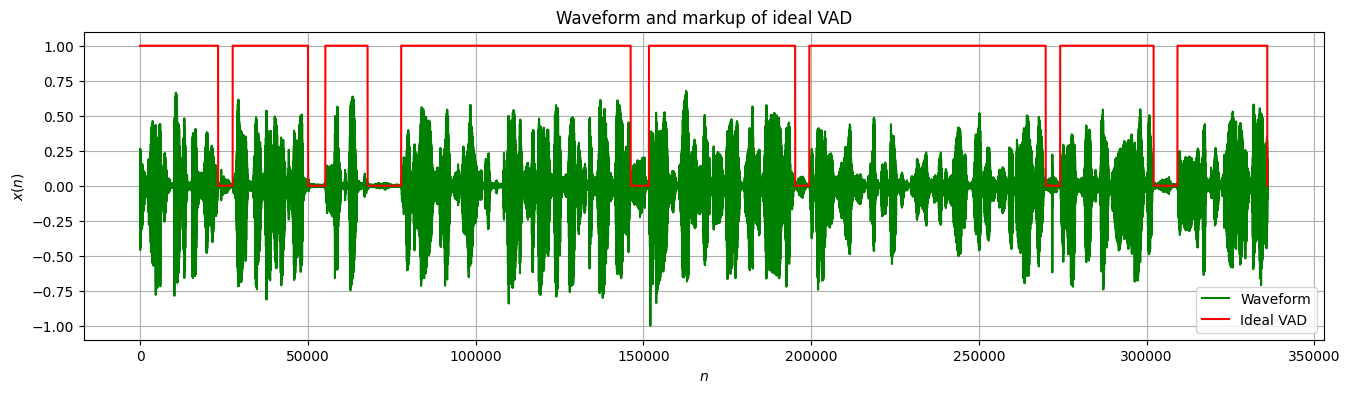

In [124]:
# Path to files
path_to_wav  = './data/voxceleb1_test/wav/id10271/1gtz-CUIygI/00006.wav'
path_to_rttm = './lab2/ground_truth/rttm/id10271_1gtz-CUIygI_00006.rttm'
path_to_wav  = './data/voxceleb1_test/wav/id10286/0sETQ5nxvf8/00001.wav'
path_to_rttm = './lab2/ground_truth/rttm/id10286_0sETQ5nxvf8_00001.rttm'

# Load signal
signal, fs = torchaudio.load(path_to_wav)
signal = signal.numpy().squeeze(axis=0)
signal = signal/np.abs(signal).max()

# Load ideal VAD's markup
vad_markup_ideal = load_vad_markup(path_to_rttm, signal, fs)
print(vad_markup_ideal)
# Plot signal
figure(figsize=(16, 4))
plot(signal, color='green')
plot(vad_markup_ideal, color='red')
xlabel('$n$'); ylabel('$x(n)$'); title('Waveform and markup of ideal VAD'); grid(); legend(['Waveform', 'Ideal VAD']); show()

## **Paso 3) Implementación del VAD basado en GMM**

*El detector de actividad del habla*, o simplemente detector de actividad vocal, está diseñado para determinar la presencia o ausencia de habla en una grabación de sonido. La entrada del detector es la señal procesada y como salida obtendremos los instantes temporales que delimitarán los segmentos de "habla" y "no habla". Esta segmentación facilitada por el detector puede representarse de varias formas, por ejemplo, utilizando para ello un archivo RTTM, visualizándolo como una secuencia de pulsos rectangulares de duración variable superpuestos a la forma de onda de la señal procesada en el dominio del tiempo, etc. En este último caso, las secciones de discurso (i.e. "con voz") generalmente se marcan con el nivel "1", y las secciones que no son de discurso, con el nivel "0" (i.e. "sin voz").

En la actualidad, existen muchísimas alternativas diferentes para la implementación de un detector de actividad vocal, incluidas las más modernas basadas en el uso de *redes neuronales profundas* (i.e. Deep Neural Networks). Cabe señalar que el uso de un detector de actividad vocal es muy importante para resolver correctamente el problema del *reconocimiento o identificación del locutor*, ya que la calidad de los modelos aprendidos para los diferentes locutores es significativamente mejor cuando nos apoyamos para ello en grabaciones limpias en las que sólo se incluye la voz del locutor en cuestión (sin pausas, sin ruidos, etc.).

En la presente práctica pretendemos implementar un *detector de actividad vocal* basado en un *modelo de mezcla de gaussianas o GMM*.

A continuación enumeraremos el conjunto de pasos u operaciones que realizaremos para implementar el detector:

1. Descargaremos la señal de voz y el marcado para "habla" y "no habla" que deseamos obtener.

2. Dividiremos la señal de voz procesándola por medio de un enventanado, por ejemplo, rectangular, dividiéndola en segmentos o ventansa con un cierto solapamiento (tmabién llamadas frames o tramas).

3. Calcularemos la energía de la señal para cada una de las ventanas. Suponiendo que la longitud de la ventana es de $L$ muestras, la energía de la señal en la ventana se puede calcular mediante la siguiente expresión: $$E(i)=\sum_{n = 0}^{L - 1}\left | x(n + i)w(n) \right |^2,$$ donde $x(n)$ es la señal de voz que se está procesando, $w(n)$ es la función de ventana y $i$ es el paso de ventana.

4. Realizaremos la normalización y escalado de las energías de las ventanas por el valor promedio y el valor cuadrático medio de la energía calculados sobre todos los segmentos de la grabación, obteniendo así las características normalizadas necesarias para entrenar el modelo de mezcla de gaussianas. Podemos calcular el valor promedio y el valor cuadrático medio de la energía para todos los segmentos de la señal procesada usando las siguientes expresiones:

<!-- Este es un comentario en Markdown, no se verá en la salida -->

$$
m_E = \frac{1}{M} \sum_{i = 0}^{M - 1} E(i)
$$

$$
\sigma_E = \left( \frac{1}{M - 1} \sum_{i=0}^{M-1} (E(i) - m_E)^2 \right)^{\frac{1}{2}}
$$

   donde $M$ es el número de segmentos en los que se dividió la señal. Las energías de segmento normalizadas y escaladas se pueden definir de la siguiente manera:

$$E_{norm}(i) = \frac{E(i) - m_E}{\sigma_E}.$$

5. Entrenaremos el modelo de mezcla de gaussianas para el caso de tres gaussianas unidimensionales utilizando las características preparadas anteriormente. En el problema bajo consideración, se supone que dos de estas gaussianas generan características correspondientes a segmentos de voz y la tercera gaussiana genera características correspondientes a segmentos que no son de voz. El entrenamiento del modelo de mezcla gaussiana se puede realizar usando el [algoritmo EM](http://www.machinelearning.ru/wiki/index.php?title=EM-%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC), que, en esencia, es una generalización probabilística del método de agrupación [k-means](https://en.wikipedia.org/wiki/K-means_clustering).
Suponga que un modelo unidimensional de mezcla de tres gaussianas sobre el conjunto de energías normalizadas $E_{norma}$ puede describirse utilizando la siguiente densidad de probabilidad:

   $$W_{E_{norm}}(e)=\sum_{j = 0}^{2}w_jW_j(e), \sum_{j = 0}^{2}w_j = 1,$$

   donde $W_j(e)$ – corresponde a la función de verosimilitud del $j$-ésimo componente de la mezcla, y para el que $w_j$ es su probabilidad a priori. Cada componente de la mezcla se puede describir mediante una función de densidad de probabilidad gaussiana: $$W_j(e) = N(e; m_j, \sigma_j) =\frac{1}{\sigma_j\sqrt{2\pi}}e^{\frac{-(e - m_j)^2}{2\sigma_j^2}},$$ donde $m_j$ y $\sigma_j$ son la media y la desviación estándar de las componentes correspondientes a la mezcla para $j = 0, 1, 2$. El *E-step* del algoritmo de entrenamiento para el modelo de mezcla de gaussianas se puede describir de la siguiente manera:

 $$g_{ij} = \frac{w_jN(E_{norm}(i); m_j, \sigma_j)}{\sum_{s = 0}^{2}w_sN(E_{norm}(i); m_s, \sigma_s)}.$$

 Por otro lado, el *M-step* del algoritmo de entrenamiento se puede describir usando las siguientes expresiones:

 $$
 w_j = \frac{1}{M} \sum_{i = 0}^{M - 1} g_{ij}
 $$

 $$
 m_j = \frac{1}{M w_j} \sum_{i = 0}^{M - 1} g_{ij} E_{\text{norm}}(i)
 $$

 $$
 \sigma_j = \left( \frac{1}{M w_j} \sum_{i = 0}^{M - 1} g_{ij} \left( E_{\text{norm}}(i) - m_j \right)^2 \right)^{\frac{1}{2}}
 $$

  donde $M$ es el número de segmentos en los que se dividió la señal.

6. Una vez entrenado el modelo, lo utilizaremos para evaluar si las diferentes ventanas pertenecen a "habla" o "no habla". Suponiendo que los valores de energía de las ventanas que no son de habla son generados por una Gaussiana con índice "0", estimaremos las probabilidades a posteriori de que la energía normalizada de la ventana $E_{norma}(i)$ se obtenga a partir de la componente 0 de la mezcla:

   $$\hat{g}_{i0} = \frac{\hat{w}_0N(E_{norm}(i); \hat{m}_0, \hat{\sigma}_0)}{\sum_{s = 0}^{2}\hat{w}_sN(E_{norm}(i); \hat{m}_s, \hat{\sigma}_s)},$$

   donde $\hat{w}_j$, $\hat{m}_j$ y $\hat{\sigma}_j$ son los parámetros entrenados del modelo de mezcla de gaussianas. Cuanto mayor sea $\hat{g}_{i0}$ para el valor seleccionado de $E_{norm}(i)$, más probable es que la ventana correspondiente no sea de voz.

7. **Seleccionaremos el umbral de decisión adecuado para el detector de actividad vocal**.

8. Etiquetaremos ventana a ventana (o trama a trama) el resultado de nuestro detector, marcando las ventanas de "habla" con el símbolo "1" y las ventanas de "no habla" con el símbolo "0". Este procedimiento se puede realizar comparando el valor $\hat{g}_{i0}$ (i.e. el posterior) para el valor $E_{norm}(i)$ seleccionado con el umbral del detector especificado. Si el valor de $\hat{g}_{i0}$ está por debajo del umbral, se supone que el segmento es de voz; de lo contrario, no es de voz. Si es necesario, el etiquetado trama a trama del detector se puede convertir en un etiquetado basado en las muestras de la señal. Este último permitirá, por ejemplo, **comparar visualmente las marcas reales y de referencia del detector superponiéndolas a la forma de onda visualizada para la grabación que se está procesando**.

In [139]:
# Squared signal
squared_signal = signal**2

# Frame signal with overlap
window = 320 # window size in samples
shift  = 160 # window shift in samples

frames = framing(squared_signal, window=window, shift=shift)

# Sum frames to get energy
E = frame_energy(frames)

# Normalize the energy
E_norm = norm_energy(E)

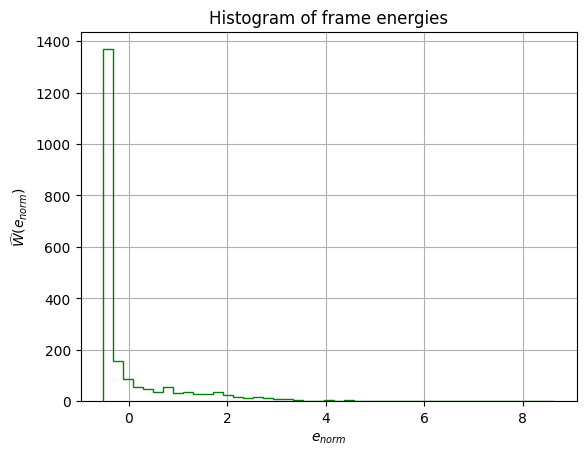

In [140]:
# Plot histograms for frame energies
hist(E_norm, int(sqrt(len(E_norm))), histtype='step', color='green')
xlabel(r'$e_{norm}$'); ylabel(r'$\widehat{W}(e_{norm})$');
title('Histogram of frame energies');
grid();
show()

In [129]:
# Gaussian probability density function
gauss_pdf = lambda value, m, sigma: 1/((abs(sigma) + 1e-10)*sqrt(2*pi))*np.exp(-(value - m)**2/(2*(abs(sigma) + 1e-10)**2))

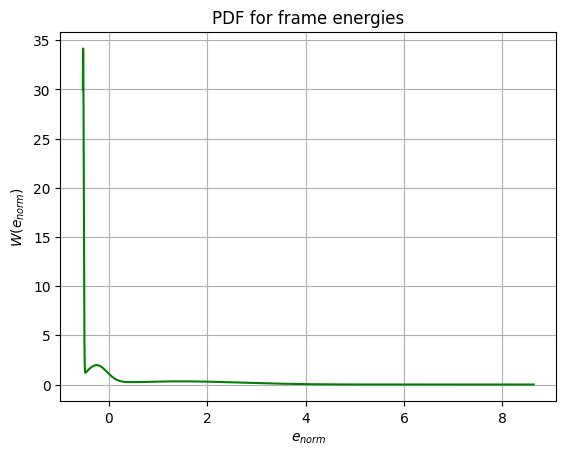

In [130]:
# Train parameters of gaussian mixture models
w, m, sigma = gmm_train(E_norm, gauss_pdf, n_realignment=10)

GMM_pdf = np.zeros(len(E_norm))
for j in range(len(m)):
    GMM_pdf = GMM_pdf + gauss_pdf(sorted(E_norm), m[j], sigma[j])

# Plot PDF for frame energies
plot(sorted(E_norm), GMM_pdf, color='green')
xlabel('$e_{norm}$'); ylabel('$W(e_{norm})$'); title('PDF for frame energies'); grid(); show()

In [142]:
# Comprueba qué frames estás marcando
print(f"Energía media de frames marcados como VOZ: {E_norm[vad_frame_markup_real == 1].mean():.4f}")
print(f"Energía media de frames marcados como SILENCIO: {E_norm[vad_frame_markup_real == 0].mean():.4f}")

Energía media de frames marcados como VOZ: 0.5326
Energía media de frames marcados como SILENCIO: -0.5200


In [131]:
# Calculamos la probabilidad a posteriori de que SEA voz (0.0 a 1.0)
# Ahora g1 = 1 significa "Voz con total seguridad"
g1 = eval_frame_post_prob(E_norm, gauss_pdf, w, m, sigma)

In [132]:
print(g1)

[0.50418668 0.66335237 0.65369883 ... 0.60715731 0.60383907 0.58810997]


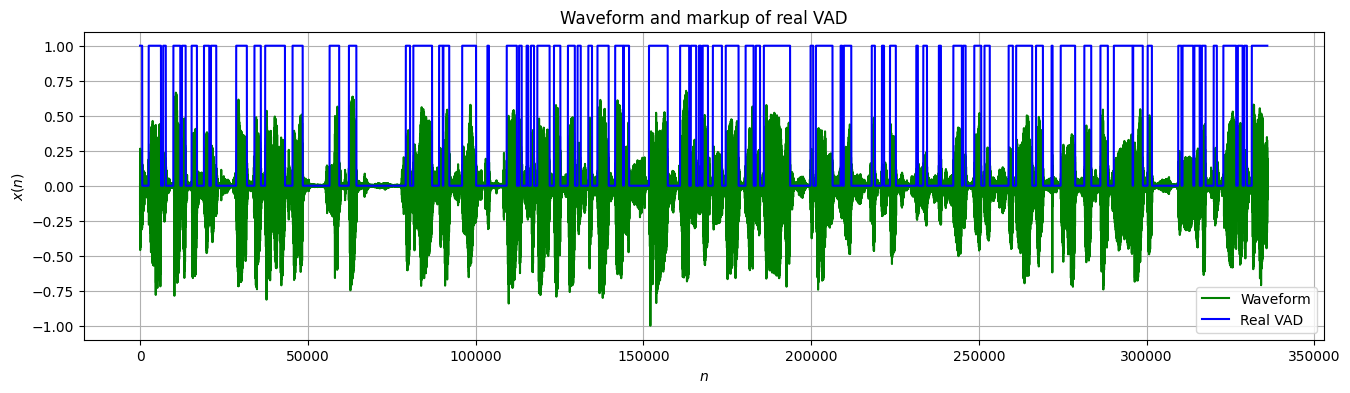

In [135]:
# Compute real VAD's markup
vad_thr = 0.3 # threshold of voice activity detector

# Aplicamos el umbral: Si la probabilidad supera el 30% (o 50%), marcamos como voz
vad_frame_markup_real = (g1 > vad_thr).astype('float32')

# Repite cada decisión del frame 'shift' veces y recorta al largo de la señal original
vad_markup_real = np.repeat(vad_frame_markup_real, shift)[:len(signal)]

# Si la señal es un poco más larga que los frames procesados, rellena con la última decisión
if len(vad_markup_real) < len(signal):
    padding = np.full(len(signal) - len(vad_markup_real), vad_frame_markup_real[-1])
    vad_markup_real = np.concatenate([vad_markup_real, padding])

# Plot signal
figure(figsize=(16, 4))
plot(signal, color='green')
plot(vad_markup_real, color='blue')
xlabel('$n$'); ylabel('$x(n)$'); title('Waveform and markup of real VAD'); grid(); legend(['Waveform', 'Real VAD']); show()

## **Paso 4) Corrección mediante métodos de procesamiento morfológico**

El análisis de la segmentación obtenida utilizando el detector de actividad vocal anterior muestra que difiere mucho de la segementación de referencia (en particular, en cuanto a los segmentos de voz no detectados). Podemos intentar mejorar la segmentación del detector, si es necesario, utilizando los métodos de [filtrado morfológico](http://www.theobjects.com/dragonfly/dfhelp/4-0/Content/05_Image%20Processing/Morphology%20Filters.htm), utilizados en el procesado de imágenes una vez éstas han sido *binarizadas*, de modo que en cada imagen sólo se observan dos tipos de píxeles: "blancos" y "negros" (según su nivel de brillo). De hecho, la segmentación realizada por el detector se puede considerar como una única fila o columna de una imagen digital binaria (i.e. sucesión de 0s y 1s en la que los 1s determinan las zonas en las que se observó "habla"). Por lo tanto, usaremos el *filtrado morfológico* para mejorar la segmentación realizada por nuestro detector.

Los procedimientos clave para el *procesamiento morfológico* son los siguientes:

1. *Dilatación* - se trata de un procedimiento de filtrado morfológico que permite aumentar el área afectada por un cierto elemento estructural dentro de una imagen digital.
2. *Erosión* - es otro procedimiento de filtrado morfológico que, al contrario que el anterior, permite reducir el área afectada por un cierto elemento estructural dentro de una imagen digital.
3. *Cierre* - procedimiento de filtrado morfológico que se basa fundamentalmente en el uso secuencial de los procedimientos de dilatación y erosión.
4. *Apertura* - procedimiento de filtrado morfológico alternativo al anterior que en este caso supone el uso secuencial de los procedimientos de erosión y dilatación.

A continuación, realizaremos diferentes experimentos con los procedimientos de cierre y apertura aplicados directamente sobre el resultado obtenido por nuestro detector.

#### **Impacto del Filtrado Morfológico (Closing) en el VAD**

El parámetro **mask_size_morph_filt** (tamaño del elemento estructurante) define la escala temporal de las correcciones en la máscara de voz. Aunque su objetivo es mejorar la coherencia de la detección, un valor mal ajustado altera drásticamente las métricas:


1.  **Propósito del Cierre (Closing)**: Esta operación realiza una dilatación seguida de una erosión. Está diseñada para "cerrar" huecos de silencio momentáneos dentro de una frase y conectar segmentos de voz que han sido fragmentados por el ruido.
2.   **Riesgo de valores altos**: Al usar un tamaño de ventana muy grande (ej. 6000 muestras), corremos el riesgo de que el proceso de erosión elimine por completo segmentos de voz legítimos pero breves. Si la duración de una palabra es menor que el tamaño del footprint, el filtro la interpretará como "ruido de brillo" y la borrará de la máscara final.
3.   **Efecto en las métricas**:

* Un valor demasiado pequeño deja una máscara fragmentada (mucho "parpadeo" entre voz y silencio), aumentando el error por falta de continuidad.
* Un valor demasiado grande suaviza la señal en exceso, haciendo que desaparezcan ráfagas de voz cortas, lo que incrementa la tasa de Falsos Negativos (FNR) y reduce el Recall.

**Nota**: Para un rendimiento óptimo, este parámetro debe ser proporcional a la duración mínima de un fonema o palabra corta en el dataset (en VoxCeleb, los segmentos suelen ser muy dinámicos).

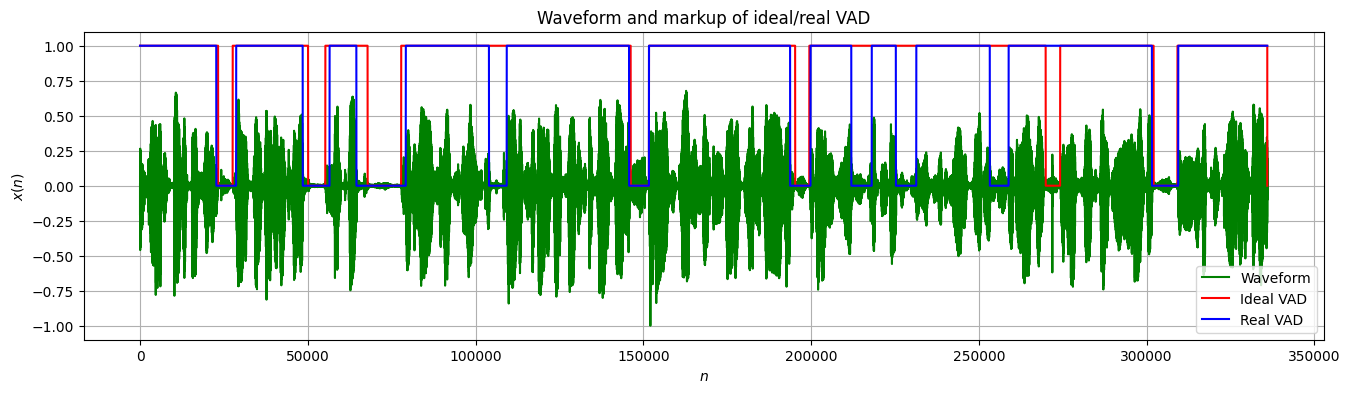

In [136]:
# Morphology Filters
# Recuerda que este filtro actúa sobre muestras.
# Si tu fs es 16,000 Hz, un filtro de 6,000 muestras son 375 ms.
# Es un tiempo razonable para unir palabras, pero si es demasiado largo,
# podrías "comerte" pausas reales entre frases.
mask_size = 4000

# Close filter
vad_markup_real_filt = closing(vad_markup_real, np.ones(mask_size))

# Open filter
vad_markup_real_filt = opening(vad_markup_real_filt, np.ones(mask_size))

# Plot signal
figure(figsize=(16, 4))
plot(signal, color='green')
plot(vad_markup_ideal, color='red')
plot(vad_markup_real_filt, color='blue')
xlabel('$n$'); ylabel('$x(n)$'); title('Waveform and markup of ideal/real VAD'); grid(); legend(['Waveform', 'Ideal VAD', 'Real VAD']); show()

## **Paso 5) Evaluación del VAD con datos "limpios"**

La mera inspección visual de las marcas obtenidas superpuestas sobre la forma de onda de de una grabación o caso determinado da una idea de la calidad del detector pero no brinda una comprensión de qué tan bien funciona "globalmente" y sobre todo no nos permite comparar efectivamente el rendimiento de un detector con otro. Para resolver este problema, se requiere utilizar métricas objetivas de evaluación de la calidad. Dado que el resultado del detector de actividad vocal es la división de la señal en secciones de dos tipos, "habla" y "no habla", en este caso podemos apoyarnos en métricas utilizadas en la teoría de decisión binaria para la evaluación de la calidad numérica. Estas métricas incluyen:
- *FRR*, tasa de falso rechazo,
- *FNR*, tasa de falsos negativos,
- *FAR*, tasa de falsa aceptación,
- *FPR*, tasa de falsos positivos,
- *P*, precisión,
- *R*, recall,
- *EER*, equal error rate, etc.
En el siguiente [enlace](https://github.com/DeepTrial/AutoMetric/blob/master/autoMetric.py) se pueden encontrar diferentes ideas para la implementación de algunas de estas métricas en relación con la evaluación de la calidad de los resultados de la segmentación binaria de imágenes digitales.

A continuación, calcularemos la FRR, FNR, FAR y la FPR, así como la precision y el recall de la muestra para un valor de umbral fijo del detector de actividad. Al calcular las métricas, asumimos que la *hipótesis nula* es la presencia de voz, y la alternativa es la ausencia de voz en algún segmento de la señal procesada. Usaremos las 20 grabaciones como set de evaluación para estimar la calidad del detector de actividad, cuyas marcas de referencia se encuentran en el directorio **./IDLO/lab2/ground_truth/rttm/**.

In [138]:
import os
import numpy as np
import torchaudio
from tqdm.notebook import tqdm
from math import sqrt, pi

# Parameters of voice activity detector
window = 320
shift  = 160
n_realignment = 10

# Gaussian probability density function
gauss_pdf = lambda value, m, sigma: 1/((abs(sigma) + 1e-10)*sqrt(2*pi))*np.exp(-(value - m)**2/(2*(abs(sigma) + 1e-10)**2))

# Path to files
path_to_wav  = './data/voxceleb1_test/wav'
path_to_rttm = './lab2/ground_truth/rttm'

TP, FP, FN, TN = 0.0, 0.0, 0.0, 0.0
rttm_files = os.listdir(path_to_rttm)

# Use tqdm for progress bar
pbar = tqdm(rttm_files, desc="Processing files")
for rttm_file in pbar:
    # Load signal
    signal, fs = torchaudio.load(os.path.join(path_to_wav, rttm_file[:7], rttm_file[8:19], '.'.join([rttm_file[20:25], 'wav'])))
    signal = signal.numpy().squeeze(axis=0)
    signal = signal / np.abs(signal).max()

    # Load ideal VAD's markup
    vad_markup_ideal = load_vad_markup(os.path.join(path_to_rttm, rttm_file), signal, fs)

    # Compute real VAD's markup
    vad_markup_real = energy_gmm_vad(signal, window, shift, gauss_pdf, n_realignment, vad_thr, mask_size_morph_filt)

    # Asegurar misma longitud (hacer trimming al más corto)
    min_len = min(len(vad_markup_ideal), len(vad_markup_real))
    v_ideal = vad_markup_ideal[:min_len]
    v_real  = vad_markup_real[:min_len]

    # Ahora calcular con los vectores alineados
    TP += np.sum((v_ideal == 1) & (v_real == 1))
    TN += np.sum((v_ideal == 0) & (v_real == 0))
    FP += np.sum((v_ideal == 0) & (v_real == 1))
    FN += np.sum((v_ideal == 1) & (v_real == 0))

    # Esto añade info extra a la derecha de la barra
    pbar.set_postfix({"status": "calculating..."})

FNR = FN / (FN + TP) if (FN + TP) > 0 else 0  # false negative rate
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0  # false positive rate
P   = TP / (TP + FP) if (TP + FP) > 0 else 0  # precision
R   = TP / (TP + FN) if (TP + FN) > 0 else 0  # recall

print('\n[SUMMARY OF RESULTS WITH CLEAN DATA]')
print('\nThreshold value:      {0:.3f}'.format(vad_thr))
print('False negative rate:  {0:.3f}'.format(FNR))
print('False positive rate:  {0:.3f}'.format(FPR))
print('Precision:            {0:.3f}'.format(P))
print('Recall:               {0:.3f}'.format(R))

Processing files:   0%|          | 0/20 [00:00<?, ?it/s]

DEBUG: id10306_2SaEbN8hYz4_00002.rttm | Voz en etiquetas: 86.5%
DEBUG: id10279_4Q1IvdayPR8_00008.rttm | Voz en etiquetas: 84.3%
DEBUG: id10271_1gtz-CUIygI_00006.rttm | Voz en etiquetas: 84.3%
DEBUG: id10276_5WOZXLMujwY_00003.rttm | Voz en etiquetas: 81.5%
DEBUG: id10284_EoCPhxtWUOc_00004.rttm | Voz en etiquetas: 84.3%
DEBUG: id10280_9AtE4C309P8_00013.rttm | Voz en etiquetas: 87.8%
DEBUG: id10288_dRr05CxK0jQ_00001.rttm | Voz en etiquetas: 91.2%
DEBUG: id10303_R5JGtwc4o1M_00002.rttm | Voz en etiquetas: 86.4%
DEBUG: id10289_3g9CjhcNEWk_00004.rttm | Voz en etiquetas: 83.3%
DEBUG: id10290_0bA1AJCGEOo_00003.rttm | Voz en etiquetas: 88.0%
DEBUG: id10299_fUs5d-C3k5E_00002.rttm | Voz en etiquetas: 94.2%
DEBUG: id10281_eso-dEmfC_c_00005.rttm | Voz en etiquetas: 84.7%
DEBUG: id10275_CVUXDNZzcmA_00002.rttm | Voz en etiquetas: 83.7%
DEBUG: id10278_d6WJf6TOoIQ_00007.rttm | Voz en etiquetas: 86.2%
DEBUG: id10272_dkN2DIBrXqQ_00008.rttm | Voz en etiquetas: 87.7%
DEBUG: id10302_K2_D_tFdAgY_00009.rttm | 

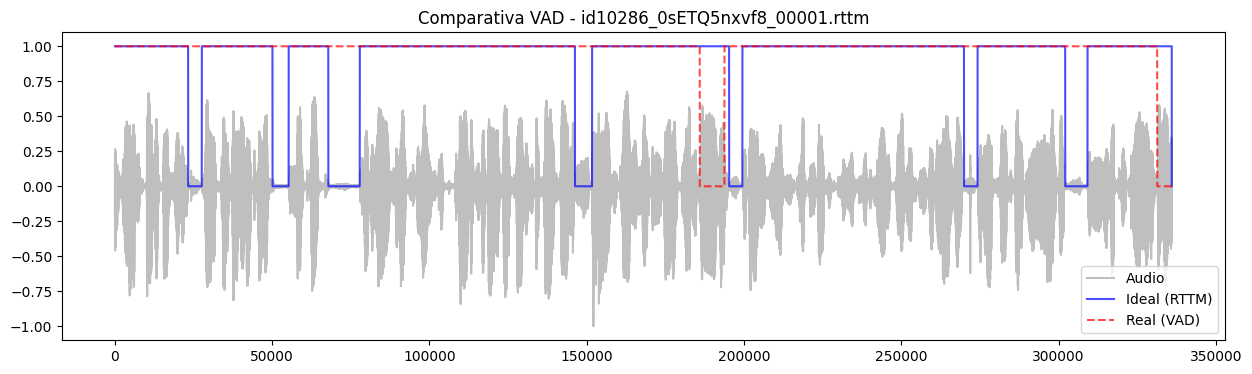

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
plt.plot(signal, color='gray', alpha=0.5, label='Audio')
plt.plot(vad_markup_ideal, color='blue', label='Ideal (RTTM)', alpha=0.7)
plt.plot(vad_markup_real, color='red', linestyle='--', label='Real (VAD)', alpha=0.7)
plt.title(f"Comparativa VAD - {rttm_file}")
plt.legend()
plt.show()

## **Paso 6) Evaluación del detector de actividad vocal implementado con datos "ruidosos"**

Los procedimientos para la generación y transmisión de una señal de voz pueden verse afectados por la influencia del ruido y la interferencias, lo que provoca la distorsión de la señal. Ejemplos de factores distorsionadores que llevan al deterioro de la calidad de una señal de voz incluyen: la reverberación de la sala, el ruido de fondo, el sonido de un televisor o radio, etc. El desarrollo de un sistema de identificación de locutores requiere tener en cuenta el impacto de tales factores de distorsión en la calidad del funcionamiento tanto de los bloques individuales como de todo el sistema en su conjunto. Dado que las etapas individuales de los sistemas de identificación de locutores modernos se implementan utilizando redes neuronales profundas que requieren grandes cantidades de datos para el entrenamiento, una posible opción para tener en cuenta las distorsiones que afectan al sistema puede ser expandir el conjunto de datos de entrenamiento de nuestros modelos a través de los métodos de aumento de datos (i.e. Data Augmentation). La *aumentación* es una técnica para crear ejemplos de entrenamiento adicionales a partir de los datos ya disponibles. Como regla general, al resolver el problema del aumento de datos en el procesamiento del habla, se utilizan bases de datos adicionales de ruido e interferencia. Los ejemplos incluyen [SLR17](https://openslr.org/17/) (corpus de grabaciones de sonido de música, voz y ruido) y [SLR28](https://openslr.org/28/) (base de datos de reverberación de salas reales y simuladas, así como ruidos isotrópicos y puntuales).

A continuación, consideraremos las técnicas de aumento de datos que simulan el efecto de la *reverberación* y de la *adición de ruido gaussiano blanco (AWGN)* en una señal de voz y analizaremos su influencia en la calidad del detector de actividad vocal. Los pasos a seguir serán los siguientes:

1. Simularemos el efecto de la reverberación en una sala utilizando un *filtro lineal invariante de corte*. Para modelar dicho efecto, se propone utilizar la reverberación propia de la [Catedral de Lausana](https://en.wikipedia.org/wiki/Lausanne_Cathedral), que fue medida por Dokmanich I. y sus colegas, quienes registraron el sonido de un globo estallando en la catedral.

2. Modelaremos el efecto del ruido aditivo usando el modelo AWGN para diferentes niveles de potencia de ruido.

3. Probaremos el detector de actividad vocal en presencia de reverberación o AWGN utilizando las métricas de evaluación de calidad numérica descritas anteriormente.

In [121]:
import os
import numpy as np
import torchaudio
from tqdm.notebook import tqdm
from math import sqrt, pi
from torchaudio.transforms import Resample

# Parameters of voice activity detector
window = 320
shift  = 160
n_realignment = 10

# Gaussian probability density function
gauss_pdf = lambda value, m, sigma: 1/((abs(sigma) + 1e-10)*sqrt(2*pi))*np.exp(-(value - m)**2/(2*(abs(sigma) + 1e-10)**2))

# Path to files
path_to_wav  = './data/voxceleb1_test/wav'
path_to_rttm = './lab2/ground_truth/rttm'

aug_mode = 'reverb'  # augmentation mode ('reverb' or 'awgn')

TP, FP, FN, TN = 0.0, 0.0, 0.0, 0.0
rttm_files = os.listdir(path_to_rttm)

# Use tqdm for progress bar
pbar = tqdm(rttm_files, desc="Processing files")
for rttm_file in pbar:
    # Load signal
    signal, fs = torchaudio.load(os.path.join(path_to_wav, rttm_file[:7], rttm_file[8:19], '.'.join([rttm_file[20:25], 'wav'])))
    signal = signal.numpy().squeeze(axis=0)
    signal = signal / np.abs(signal).max()

    if aug_mode == 'reverb':
        impulse_response, ir_fs = torchaudio.load('./lab2/cathIR.wav')
        resample = Resample(orig_freq=ir_fs, new_freq=fs, resampling_method='sinc_interpolation')
        impulse_response = resample(impulse_response)
        impulse_response = impulse_response.numpy().squeeze(axis=0)
        impulse_response = impulse_response / np.abs(impulse_response).max()
        signal = reverb(signal, impulse_response)
    else:
        sigma_noise = 0.15
        signal = awgn(signal, sigma_noise)

    # Load ideal VAD's markup
    vad_markup_ideal = load_vad_markup(os.path.join(path_to_rttm, rttm_file), signal, fs)

    # Compute real VAD's markup
    vad_markup_real = energy_gmm_vad(signal, window, shift, gauss_pdf, n_realignment, vad_thr, mask_size_morph_filt)

    # Asegurar misma longitud (hacer trimming al más corto)
    min_len = min(len(vad_markup_ideal), len(vad_markup_real))
    v_ideal = vad_markup_ideal[:min_len]
    v_real  = vad_markup_real[:min_len]

    # Ahora calcular con los vectores alineados
    TP += np.sum((v_ideal == 1) & (v_real == 1))
    TN += np.sum((v_ideal == 0) & (v_real == 0))
    FP += np.sum((v_ideal == 0) & (v_real == 1))
    FN += np.sum((v_ideal == 1) & (v_real == 0))

    # Esto añade info extra a la derecha de la barra
    pbar.set_postfix({"status": "calculating..."})

FNR = FN / (FN + TP) if (FN + TP) > 0 else 0  # false negative rate
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0  # false positive rate
P   = TP / (TP + FP) if (TP + FP) > 0 else 0  # precision
R   = TP / (TP + FN) if (TP + FN) > 0 else 0  # recall

print('\n[SUMMARY OF RESULTS WITH NOISY DATA]')
print('\nThreshold value:      {0:.3f}'.format(vad_thr))
print('False negative rate:  {0:.3f}'.format(FNR))
print('False positive rate:  {0:.3f}'.format(FPR))
print('Precision:            {0:.3f}'.format(P))
print('Recall:               {0:.3f}'.format(R))

Processing files:   0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_2593/3580490442.py:35: UserWarning: "sinc_interpolation" resampling method name is being deprecated and replaced by "sinc_interp_hann" in the next release. The default behavior remains unchanged.
  resample = Resample(orig_freq=ir_fs, new_freq=fs, resampling_method='sinc_interpolation')


DEBUG: id10306_2SaEbN8hYz4_00002.rttm | Voz en etiquetas: 86.5%
DEBUG: id10279_4Q1IvdayPR8_00008.rttm | Voz en etiquetas: 84.3%
DEBUG: id10271_1gtz-CUIygI_00006.rttm | Voz en etiquetas: 84.3%
DEBUG: id10276_5WOZXLMujwY_00003.rttm | Voz en etiquetas: 81.5%
DEBUG: id10284_EoCPhxtWUOc_00004.rttm | Voz en etiquetas: 84.3%
DEBUG: id10280_9AtE4C309P8_00013.rttm | Voz en etiquetas: 87.8%
DEBUG: id10288_dRr05CxK0jQ_00001.rttm | Voz en etiquetas: 91.2%
DEBUG: id10303_R5JGtwc4o1M_00002.rttm | Voz en etiquetas: 86.4%
DEBUG: id10289_3g9CjhcNEWk_00004.rttm | Voz en etiquetas: 83.3%
DEBUG: id10290_0bA1AJCGEOo_00003.rttm | Voz en etiquetas: 88.0%
DEBUG: id10299_fUs5d-C3k5E_00002.rttm | Voz en etiquetas: 94.2%
DEBUG: id10281_eso-dEmfC_c_00005.rttm | Voz en etiquetas: 84.7%
DEBUG: id10275_CVUXDNZzcmA_00002.rttm | Voz en etiquetas: 83.7%
DEBUG: id10278_d6WJf6TOoIQ_00007.rttm | Voz en etiquetas: 86.2%
DEBUG: id10272_dkN2DIBrXqQ_00008.rttm | Voz en etiquetas: 87.7%
DEBUG: id10302_K2_D_tFdAgY_00009.rttm | 

## **Paso 7) Preguntas de control**

1. ¿Cómo se organiza el archivo RTTM y con qué propósito se utiliza?
2. ¿Cómo calcular la energía de la señal?
3. ¿Qué es el modelo de mezcla de Gaussianas?
4. ¿Qué es un detector de actividad vocal?
5. ¿Cómo funciona el detector de actividad vocal basado en el cálculo de la energía y en el modelo de mezcla de gaussianas?
6. Las principales ventajas y desventajas del detector de actividad vocal basado en energías.
7. ¿Cuál es el propósito de utilizar métodos de procesamiento morfológico para corregir el resultado del detector de actividad?
8. ¿Qué métricas de evaluación de calidad numérica se pueden usar para describir el resultado del detector de actividad?
9. ¿Qué es el **"aumento de datos"** y con qué fines se utiliza?
10. ¿Cómo se puede construir un mejor detector de actividad vocal?

## **Bibliografía**

1. Bishop C.M. reconocimiento de patrones y aprendizaje automático. Springer, 2006 ([enlace](http://users.isr.ist.utl.pt/~wurmd/Livros/school/Bishop%20-%20Pattern%20Recognition%20And%20Machine%20Learning%20-%20Springer%20%202006.pdf)).
2. Beigi H. Fundamentals of speaker recogniton. Springer, 2011 ([enlace](https://www.springer.com/gp/book/9780387775913)).
3. Černocký H. Voice biometry standard proposal // Interspeech 2015, Dresden, Germany, 2015 ([enlace](https://voicebiometry.org/)).